In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load drug names
drug_names = pd.read_csv('/content/drug_names.tsv', sep='\t',header=None, names=['STITCH_ID', 'Drug_Name'])
drug_names.columns=drug_names.columns.str.lower()

In [ ]:
drug_names.head()

,stitch_id,drug_name
0,CID100000085,carnitine
1,CID100000119,gamma-aminobutyric
2,CID100000137,5-aminolevulinic
3,CID100000143,leucovorin
4,CID100000146,5-methyltetrahydrofolate


In [ ]:
drug_names.isna().sum()

,0
stitch_id,0
drug_name,0


In [ ]:
#Load indications data
indications=pd.read_csv('/content/meddra_all_indications.tsv', sep='\t',header=None,
                          names=['STITCH_ID', 'UMLS_ID', 'Detection_Method', 'Indication_Name', 'MedDRA_Type', 'UMLS_ID2', 'MedDRA_Indication_Name'])
indications.columns=indications.columns.str.lower()
indications.head()

,stitch_id,umls_id,detection_method,indication_name,meddra_type,umls_id2,meddra_indication_name
0,CID100000085,C0015544,text_mention,Failure to Thrive,LLT,C0015544,Failure to thrive
1,CID100000085,C0015544,text_mention,Failure to Thrive,PT,C0015544,Failure to thrive
2,CID100000085,C0020615,text_mention,Hypoglycemia,LLT,C0020615,Hypoglycaemia
3,CID100000085,C0020615,text_mention,Hypoglycemia,PT,C0020615,Hypoglycaemia
4,CID100000085,C0022661,NLP_indication,"Kidney Failure, Chronic",LLT,C0022661,Renal failure chronic


In [ ]:
indications.value_counts()

stitch_id     umls_id   detection_method  indication_name                   meddra_type  umls_id2  meddra_indication_name      
CID171306834  C0856536  text_mention      Philadelphia chromosome positive  PT           C0476431  Chromosome analysis abnormal    1
CID100000085  C0015544  text_mention      Failure to Thrive                 LLT          C0015544  Failure to thrive               1
                                                                            PT           C0015544  Failure to thrive               1
              C0020615  text_mention      Hypoglycemia                      LLT          C0020615  Hypoglycaemia                   1
                                                                            PT           C0020615  Hypoglycaemia                   1
                                                                                                                                  ..
              C0151786  text_mention      Muscle Weakness                   LLT          C0151786  Muscular weakness               1
                                                                            PT           C0151786  Muscular weakness               1
              C0878544  text_mention      Cardiomyopathies                  LLT          C0878544  Cardiomyopathy                  1
                                                                            PT           C0878544  Cardiomyopathy                  1
              C1142132  NLP_indication    Carnitine deficiency              LLT          C1142132  Carnitine deficiency            1
Name: count, Length: 30794, dtype: int64

In [ ]:
indications.isna().sum()

,0
stitch_id,0
umls_id,0
detection_method,0
indication_name,0
meddra_type,41
umls_id2,41
meddra_indication_name,0


In [ ]:
#Merge indications with drug names
merged_indications = pd.merge(indications, drug_names, on="stitch_id",how="left")
merged_indications.drop_duplicates(inplace=True)
merged_indications.dropna(inplace=True)
merged_indications.head()

,stitch_id,umls_id,detection_method,indication_name,meddra_type,umls_id2,meddra_indication_name,drug_name
0,CID100000085,C0015544,text_mention,Failure to Thrive,LLT,C0015544,Failure to thrive,carnitine
1,CID100000085,C0015544,text_mention,Failure to Thrive,PT,C0015544,Failure to thrive,carnitine
2,CID100000085,C0020615,text_mention,Hypoglycemia,LLT,C0020615,Hypoglycaemia,carnitine
3,CID100000085,C0020615,text_mention,Hypoglycemia,PT,C0020615,Hypoglycaemia,carnitine
4,CID100000085,C0022661,NLP_indication,"Kidney Failure, Chronic",LLT,C0022661,Renal failure chronic,carnitine


In [ ]:
#Load side effects data
side_effects=pd.read_csv('/content/meddra_all_se.tsv', sep='\t',header=None,
                        names=['STITCH_ID_flat','STITCH_ID_stereo', 'UMLS_ID', 'Concept_Type', 'MedDRA_UMLS_ID', 'Side_Effect_Name'])
side_effects.columns=side_effects.columns.str.lower()
side_effects.head()

,stitch_id_flat,stitch_id_stereo,umls_id,concept_type,meddra_umls_id,side_effect_name
0,CID100000085,CID000010917,C0000729,LLT,C0000729,Abdominal cramps
1,CID100000085,CID000010917,C0000729,PT,C0000737,Abdominal pain
2,CID100000085,CID000010917,C0000737,LLT,C0000737,Abdominal pain
3,CID100000085,CID000010917,C0000737,PT,C0687713,Gastrointestinal pain
4,CID100000085,CID000010917,C0000737,PT,C0000737,Abdominal pain


In [ ]:
#Merge side effects with drug names
merged_se = pd.merge(side_effects, drug_names, left_on="stitch_id_flat",right_on='stitch_id',how="left")
merged_se.drop_duplicates(inplace=True)
merged_se.dropna(inplace=True)
merged_se.drop(columns=['stitch_id'],inplace=True)
merged_se.head()

,stitch_id_flat,stitch_id_stereo,umls_id,concept_type,meddra_umls_id,side_effect_name,drug_name
0,CID100000085,CID000010917,C0000729,LLT,C0000729,Abdominal cramps,carnitine
1,CID100000085,CID000010917,C0000729,PT,C0000737,Abdominal pain,carnitine
2,CID100000085,CID000010917,C0000737,LLT,C0000737,Abdominal pain,carnitine
3,CID100000085,CID000010917,C0000737,PT,C0687713,Gastrointestinal pain,carnitine
4,CID100000085,CID000010917,C0000737,PT,C0000737,Abdominal pain,carnitine


In [ ]:
merged_se.shape

(308948, 7)

In [ ]:
print(f'Merged_indications size={merged_indications.shape}')
print(f'Merged_se size={merged_se.shape}')

Merged_indications size=(30476, 8)
Merged_se size=(308948, 7)


In [ ]:
#Merge side effects and indications together
df = pd.merge(merged_se, merged_indications, left_on='stitch_id_flat', right_on='stitch_id', how='inner', suffixes=('_se', '_ind'))
df.drop(columns=['stitch_id'], inplace=True)

df.head()

,stitch_id_flat,stitch_id_stereo,umls_id_se,concept_type,meddra_umls_id,side_effect_name,drug_name_se,umls_id_ind,detection_method,indication_name,meddra_type,umls_id2,meddra_indication_name,drug_name_ind
0,CID100000085,CID000010917,C0000729,LLT,C0000729,Abdominal cramps,carnitine,C0015544,text_mention,Failure to Thrive,LLT,C0015544,Failure to thrive,carnitine
1,CID100000085,CID000010917,C0000729,LLT,C0000729,Abdominal cramps,carnitine,C0015544,text_mention,Failure to Thrive,PT,C0015544,Failure to thrive,carnitine
2,CID100000085,CID000010917,C0000729,LLT,C0000729,Abdominal cramps,carnitine,C0020615,text_mention,Hypoglycemia,LLT,C0020615,Hypoglycaemia,carnitine
3,CID100000085,CID000010917,C0000729,LLT,C0000729,Abdominal cramps,carnitine,C0020615,text_mention,Hypoglycemia,PT,C0020615,Hypoglycaemia,carnitine
4,CID100000085,CID000010917,C0000729,LLT,C0000729,Abdominal cramps,carnitine,C0022661,NLP_indication,"Kidney Failure, Chronic",LLT,C0022661,Renal failure chronic,carnitine


In [ ]:
df.shape

(10469014, 14)

In [ ]:
#Drop unnecessary columns and rename
df.drop(columns=[
    "stitch_id_stereo", "meddra_umls_id", "drug_name_se",
    "umls_id_ind", "detection_method", "indication_name"
], inplace=True)

# Rename `drug_name_ind` to just `drug_name` for clarity
df.rename(columns={"drug_name_ind": "drug_name"}, inplace=True)

df.rename(columns={"drugname_se": "drug_name"}, inplace=True)
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

In [ ]:
df.shape

(9312040, 8)

In [ ]:
df.rename(columns={'meddra_indication_name':'indication_name'},inplace=True)

In [ ]:
df.head()

,stitch_id_flat,umls_id_se,concept_type,side_effect_name,meddra_type,umls_id2,indication_name,drug_name
0,CID100000085,C0000729,LLT,Abdominal cramps,LLT,C0015544,Failure to thrive,carnitine
1,CID100000085,C0000729,LLT,Abdominal cramps,PT,C0015544,Failure to thrive,carnitine
2,CID100000085,C0000729,LLT,Abdominal cramps,LLT,C0020615,Hypoglycaemia,carnitine
3,CID100000085,C0000729,LLT,Abdominal cramps,PT,C0020615,Hypoglycaemia,carnitine
4,CID100000085,C0000729,LLT,Abdominal cramps,LLT,C0022661,Renal failure chronic,carnitine


In [ ]:
#Save cleaned merged file
df.to_csv('merged_data.csv',index=False)

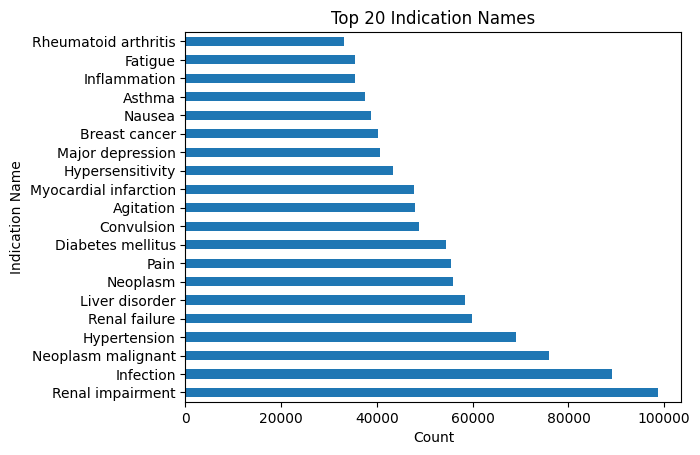

<Figure size 1000x1000 with 0 Axes>

In [ ]:
df['indication_name'].value_counts().head(20).plot(kind='barh',xlabel='Count',
                                               ylabel='Indication Name',title='Top 20 Indication Names')
plt.figure(figsize=(10,10))
plt.show()


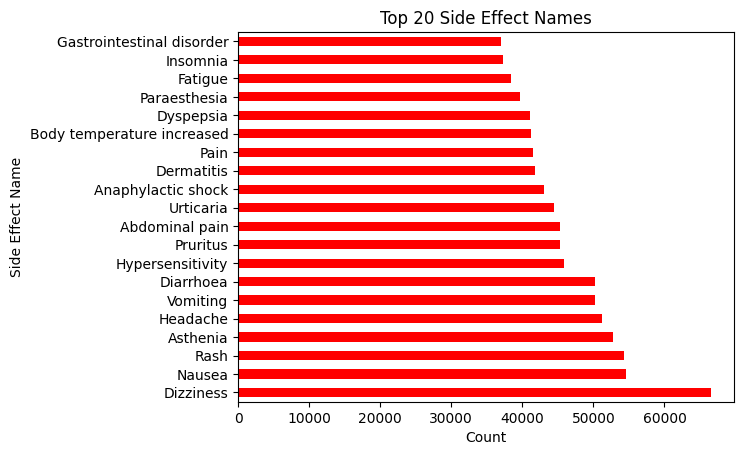

<Figure size 1000x1000 with 0 Axes>

In [ ]:
df['side_effect_name'].value_counts().head(20).plot(kind='barh',xlabel='Count',
                                               ylabel='Side Effect Name',title='Top 20 Side Effect Names', color ='red')
plt.figure(figsize=(10,10))
plt.show()